In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("deliveries.csv")
matches=pd.read_csv("matches.csv")
df=df.fillna("not applicable")
matches=matches.fillna("not applicable")


In [4]:
df["batting_team"]=df["batting_team"].replace({
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru', 
    'Kings XI Punjab':'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
})
df["bowling_team"]=df["bowling_team"].replace({
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru', 
    'Kings XI Punjab':'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
})
matches["season"]=matches["season"].replace({
    "2007/08":"2008",
    "2009/10":"2010",
    "2020/21":"2020"
})

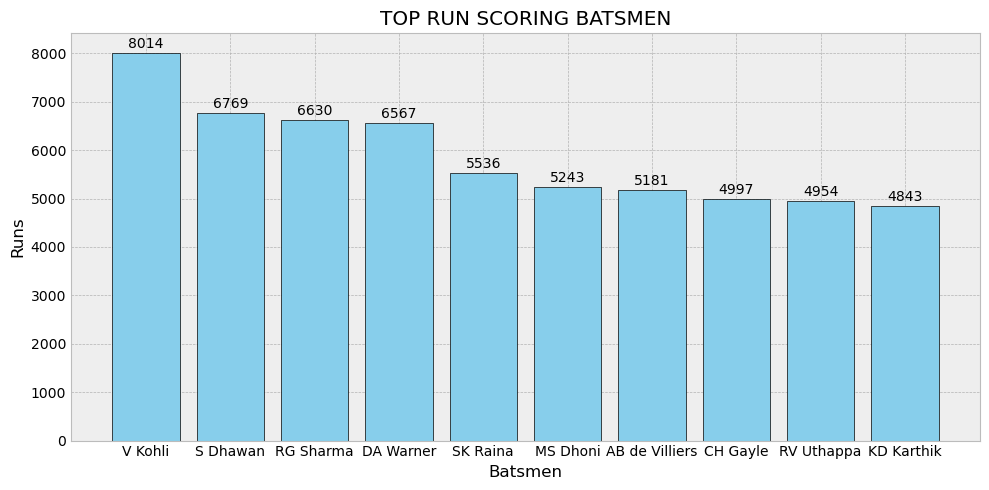

In [31]:
top_batsmens=df.groupby("batter")["batsman_runs"].sum()
sorted_top_batsmens=top_batsmens.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(sorted_top_batsmens.index, sorted_top_batsmens.values, color="skyblue", edgecolor="black")
plt.title("TOP RUN SCORING BATSMEN")
plt.ylabel("Runs")
plt.xlabel("Batsmen")
plt.style.use("Solarize_Light2")
for i in range(0,10):
    plt.text(sorted_top_batsmens.index[i], sorted_top_batsmens.values[i]+100, sorted_top_batsmens.values[i], ha="center")
plt.tight_layout()
plt.show()

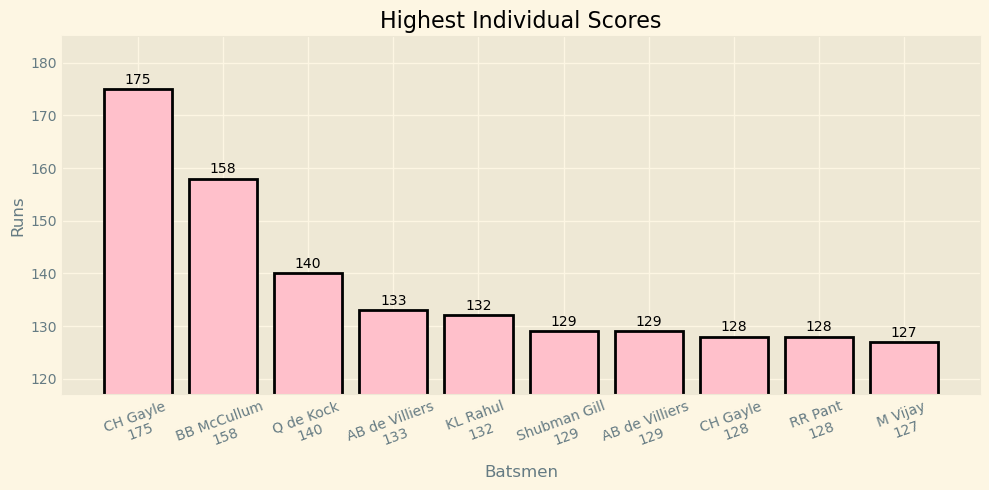

In [32]:
top_run_scorer = df.groupby(["match_id", "batter"])["batsman_runs"].sum().sort_values(ascending=False).head(10)
batsmen = top_run_scorer.index.get_level_values("batter")
runs = top_run_scorer.values
labels=[f"{batter}\n{runs}" for batter,runs in zip(batsmen, runs) ]
plt.figure(figsize=(10, 5))
plt.bar(labels, runs, 
        color="pink", 
        edgecolor="black", 
        linewidth=2)
plt.title("Highest Individual Scores")
plt.ylabel("Runs")
plt.xlabel("Batsmen")
plt.style.use("Solarize_Light2")
for i in range(len(batsmen)):
    plt.text(labels[i], runs[i]+1, runs[i], ha="center")
plt.xticks(rotation=20, ha="center")
plt.ylim(min(runs)-10, max(runs)+10)
plt.tight_layout()
plt.show()

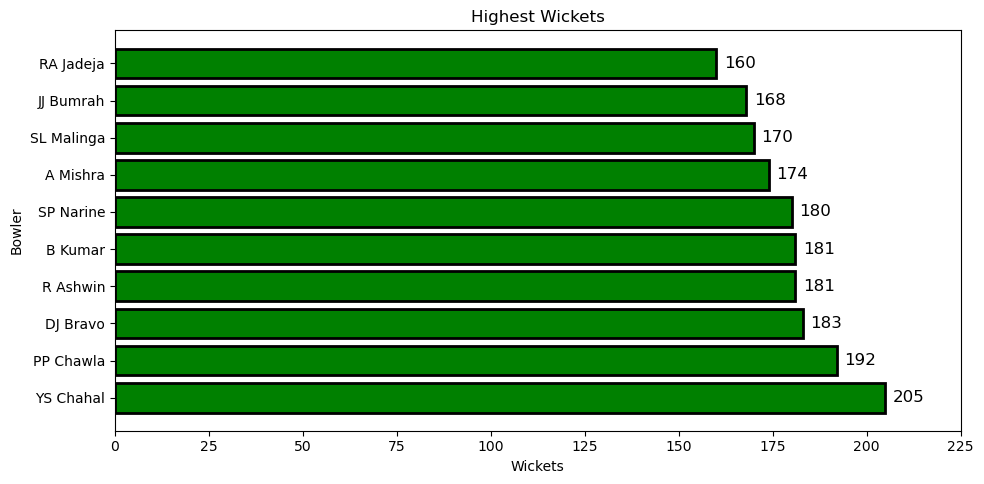

In [37]:
no_ro=df[df["dismissal_kind"] != "run out"]
top_bowlers = no_ro.groupby("bowler")["is_wicket"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_bowlers.index, top_bowlers.values,
        color="green",
        linewidth =2,
        edgecolor="black"
        )
plt.title("Highest Wickets")
plt.ylabel("Bowler")
plt.xlabel("Wickets")
for i in range(len(top_bowlers)):
    plt.text(
        top_bowlers.values[i] + 2,
        i,                          
        str(top_bowlers.values[i]), 
        va="center"
    )
plt.tight_layout()
plt.show()

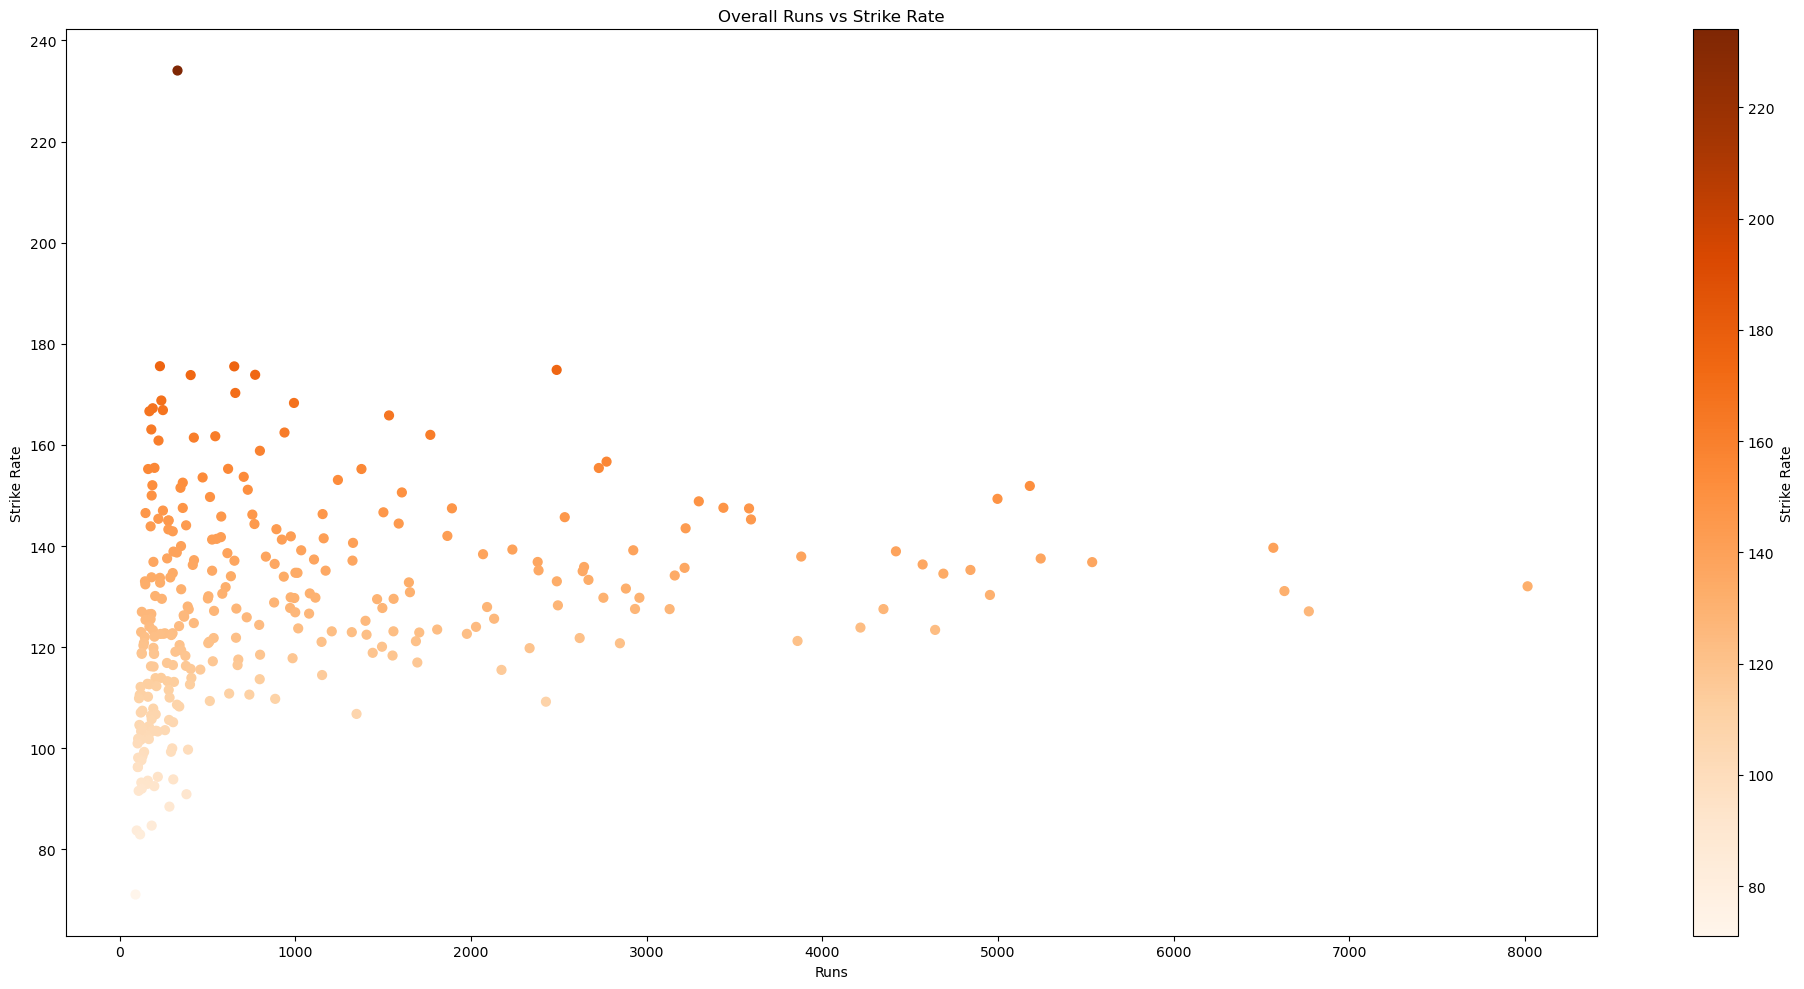

In [53]:
batsmen_runs=df.groupby("batter")["batsman_runs"].sum()

no_wd=df[df["extras_type"] != "wides"]
balls_faced=no_wd.groupby("batter").size().sort_values(ascending=False)

strike_rate=(batsmen_runs/balls_faced)*100
strike_rate=strike_rate[balls_faced >= 100].sort_values(ascending=False)
batsmen_runs=batsmen_runs[strike_rate.index]

plt.figure(figsize=(20,10))
plt.scatter(batsmen_runs.values,strike_rate.values,
            cmap="Oranges",
            c=strike_rate.values,
            s=40)
plt.title("Overall Runs vs Strike Rate")
plt.xlabel("Runs")
plt.ylabel("Strike Rate")
plt.style.use("default")
plt.colorbar(label="Strike Rate")
plt.tight_layout()
plt.show()

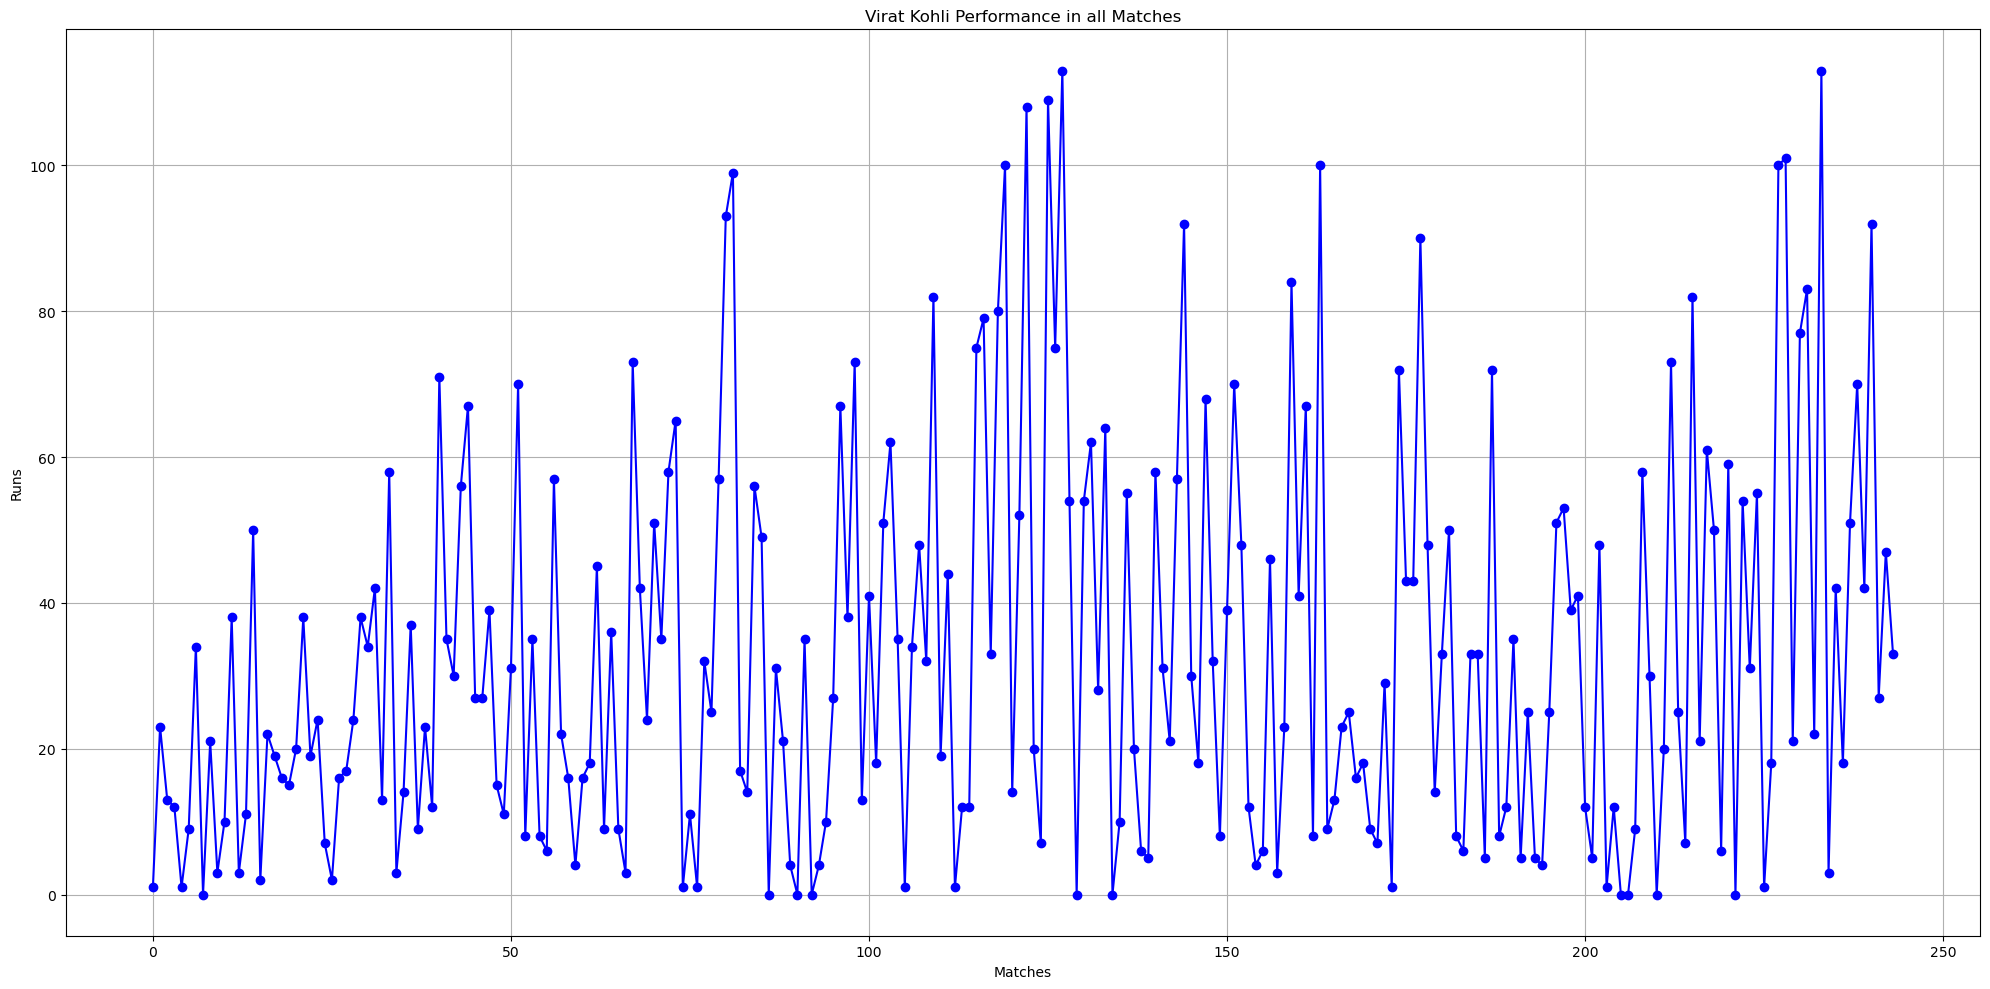

In [52]:
batsmen_runs=df.groupby(["batter", "match_id"])["batsman_runs"].sum().reset_index()
kohli=batsmen_runs[batsmen_runs["batter"]=="V Kohli"]

plt.figure(figsize=(20,10))
plt.plot(range(0,len(kohli["batsman_runs"])),kohli["batsman_runs"],"bo-")
plt.grid()
plt.title("Virat Kohli Performance in all Matches")
plt.xlabel("Matches")
plt.ylabel("Runs")
plt.tight_layout()
plt.show()

In [10]:
merged=df.merge(matches[["id", "season"]],
            left_on="match_id",
            right_on="id")


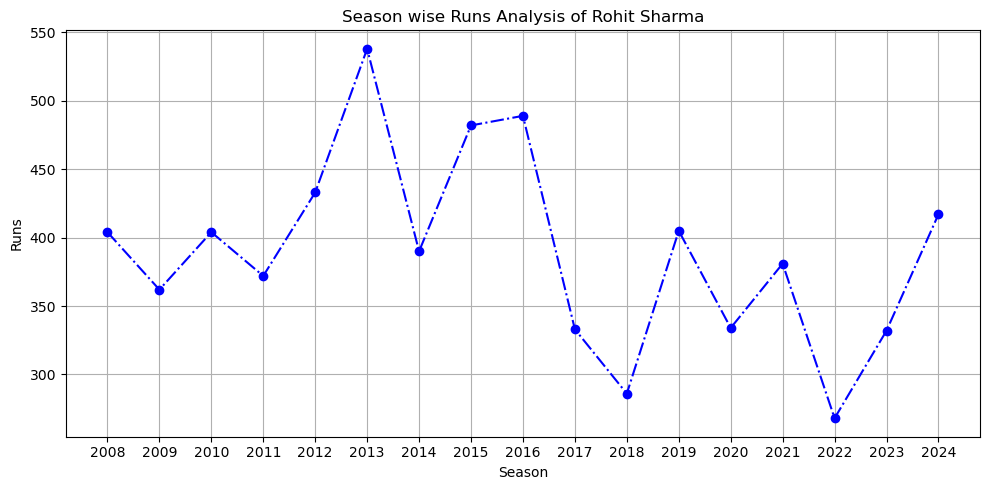

In [21]:
batsmen_season_runs=merged.groupby(["batter","season"])["batsman_runs"].sum().reset_index()
ro=batsmen_season_runs[batsmen_season_runs["batter"] == "RG Sharma"]

plt.figure(figsize=(10,5))
plt.plot(ro["season"],ro["batsman_runs"],
        "bo-.")
plt.grid()
plt.title("Season wise Runs Analysis of Rohit Sharma")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.tight_layout()
plt.show()

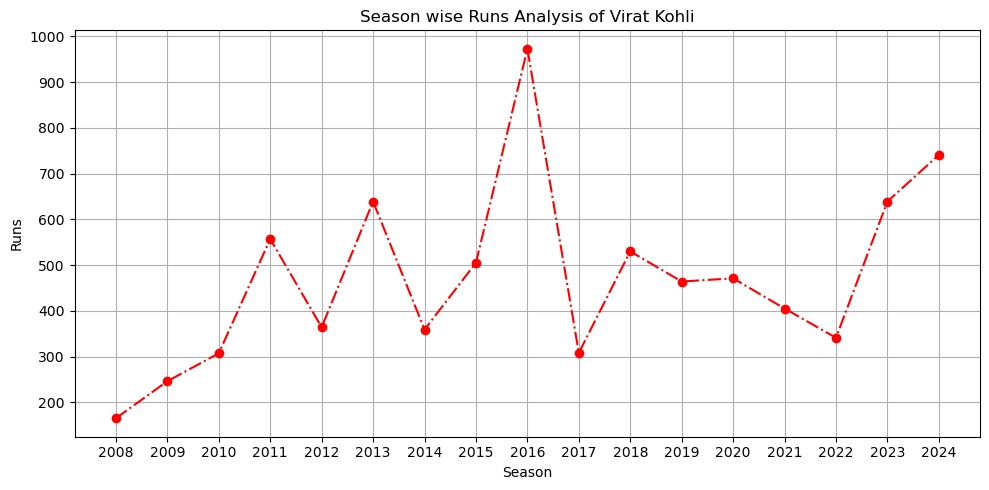

In [22]:
vk=batsmen_season_runs[batsmen_season_runs["batter"] == "V Kohli"]

plt.figure(figsize=(10,5))
plt.plot(vk["season"],vk["batsman_runs"],
        "ro-.")
plt.grid()
plt.title("Season wise Runs Analysis of Virat Kohli")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.tight_layout()
plt.show()

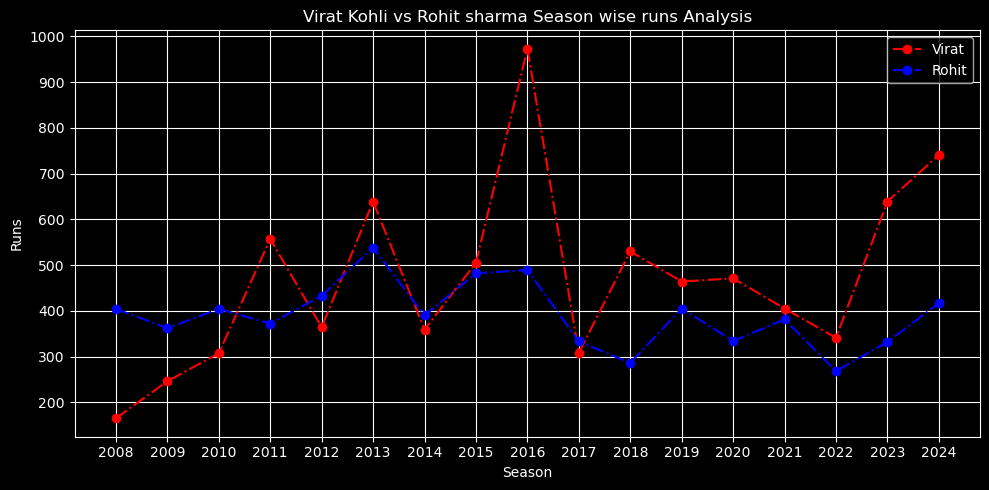

In [47]:
plt.figure(figsize=(10,5))
plt.plot(vk["season"],vk["batsman_runs"],
        "ro-.", label="Virat")
plt.plot(ro["season"],ro["batsman_runs"],
        "bo-.", label="Rohit")
plt.grid()
plt.title("Virat Kohli vs Rohit sharma Season wise runs Analysis")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.style.use("dark_background")
plt.legend()
plt.tight_layout()
plt.show()

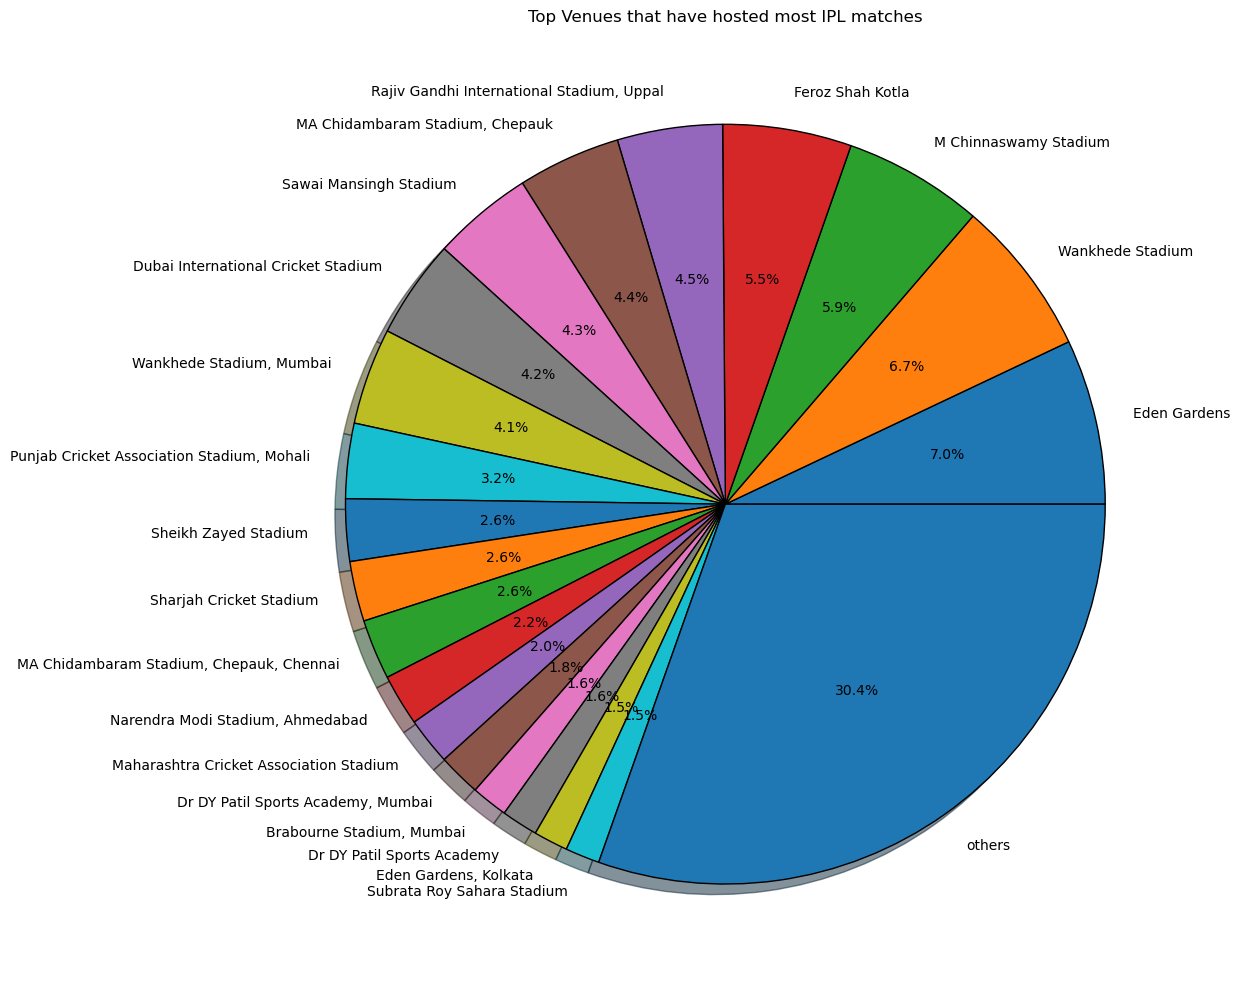

In [24]:
all_venues=matches["venue"].value_counts()
top10=all_venues.head(20)
others=all_venues.iloc[20:].sum()
pie_venue=pd.concat([
    top10,
    pd.Series({"others":others})
])

plt.figure(figsize=(20,10))
plt.pie(pie_venue,
        labels=pie_venue.index,
        autopct="%1.1f%%",
        wedgeprops={"edgecolor":"black"},
        shadow=True
       )
plt.title("Top Venues that have hosted most IPL matches")
plt.tight_layout()
plt.show()

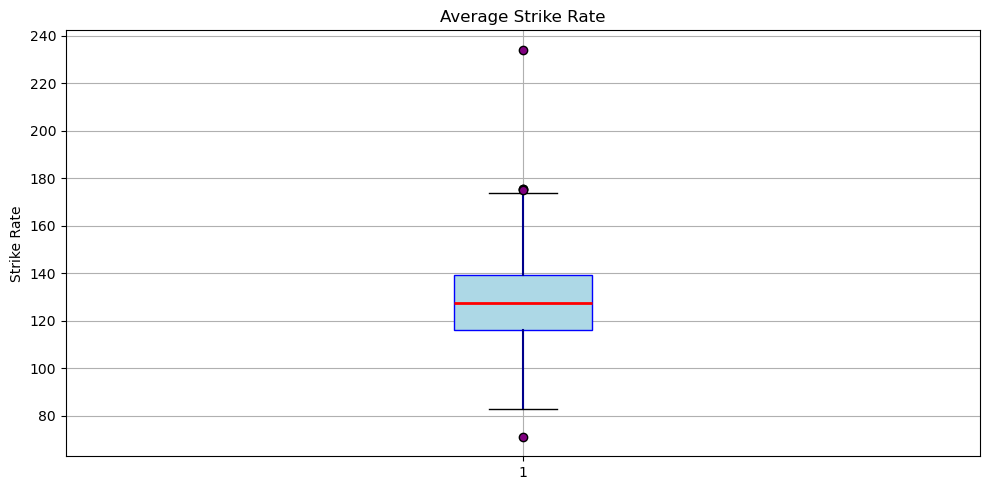

In [25]:
plt.figure(figsize=(10,5))
plt.boxplot(strike_rate.values,patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='blue'),
           whiskerprops=dict(color='darkblue', linewidth=1.5),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='purple', markersize=6))
plt.grid()
plt.title("Average Strike Rate")
plt.ylabel("Strike Rate")

plt.tight_layout()
plt.show()

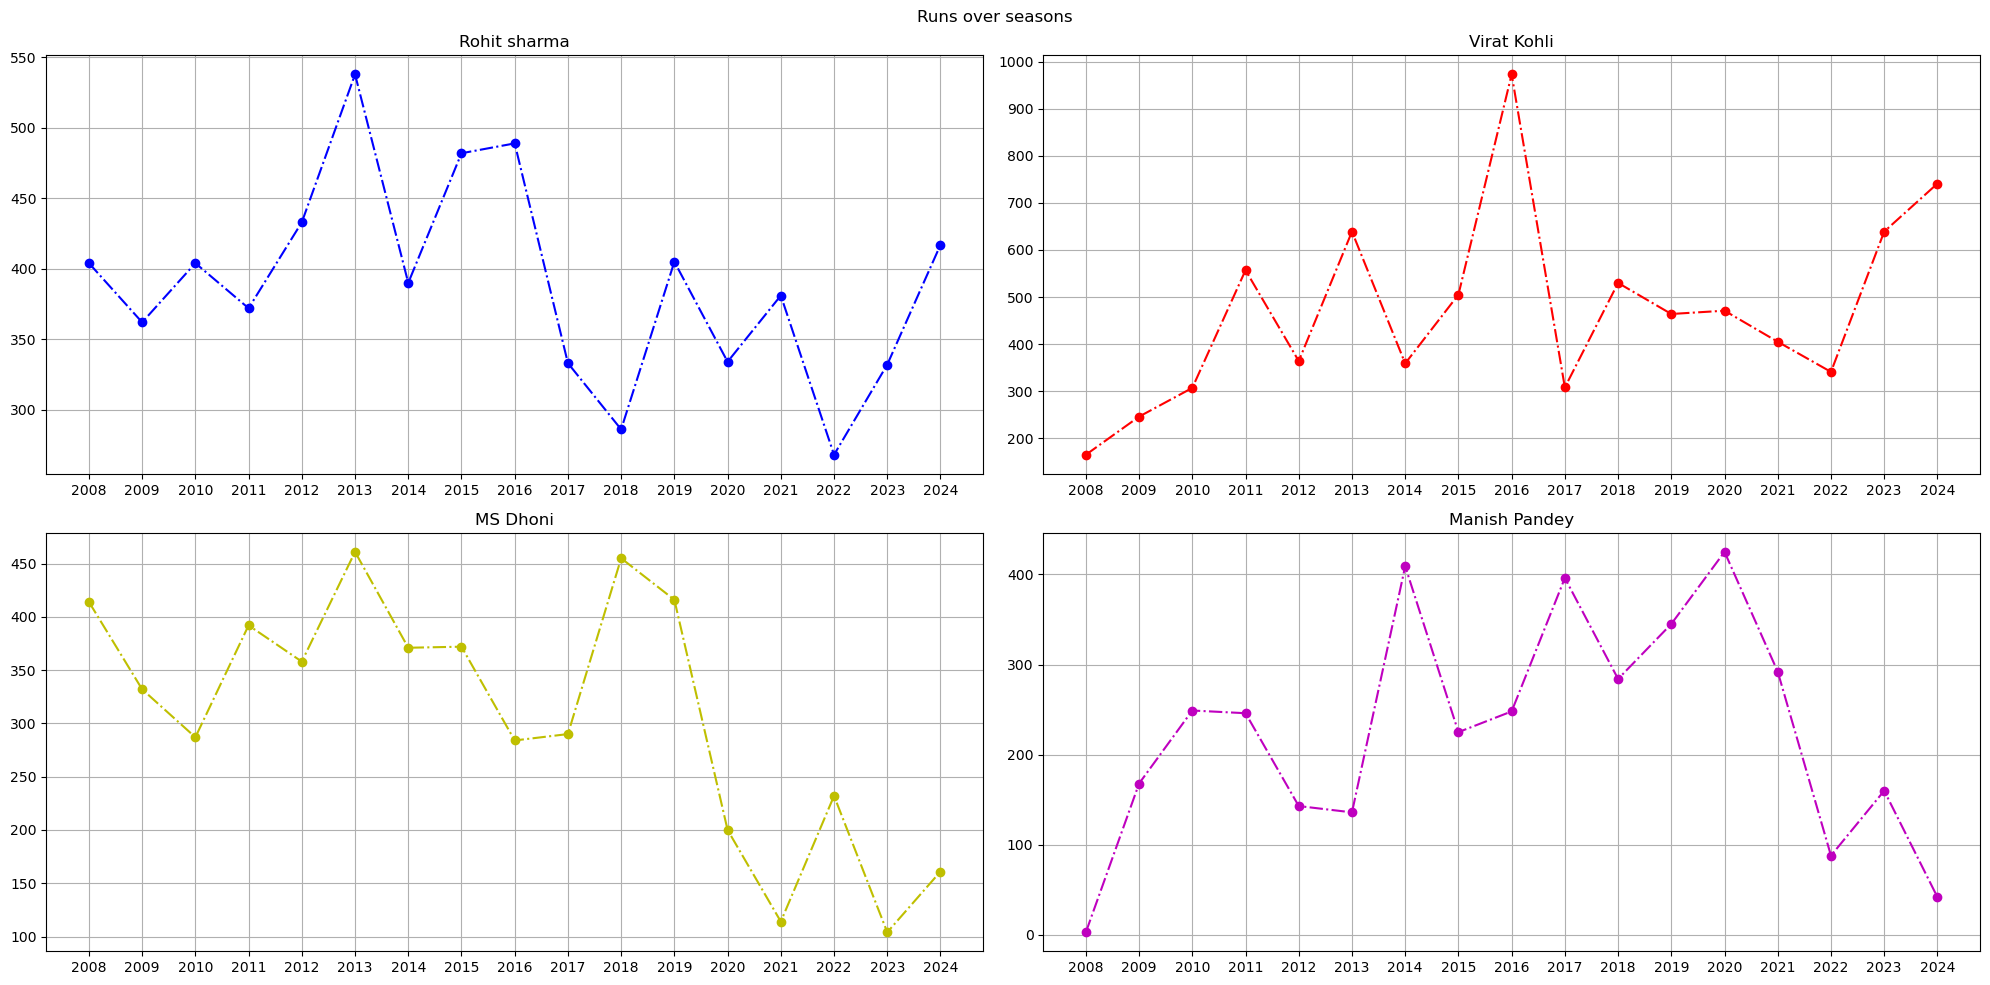

In [26]:
ms=batsmen_season_runs[batsmen_season_runs["batter"] == "MS Dhoni"]
mp=batsmen_season_runs[batsmen_season_runs["batter"] == "MK Pandey"]

plt.figure(figsize=(20,10))

plt.subplot(2,2,1)
plt.plot(ro["season"],ro["batsman_runs"],"bo-.")
plt.title("Rohit sharma")
plt.grid()


plt.subplot(2,2,2)
plt.plot(vk["season"],vk["batsman_runs"],"ro-.")
plt.title("Virat Kohli")
plt.grid()


plt.subplot(2,2,3)
plt.plot(ms["season"],ms["batsman_runs"],"yo-.")
plt.title("MS Dhoni")
plt.grid()


plt.subplot(2,2,4)
plt.plot(mp["season"],mp["batsman_runs"],"mo-.")
plt.title("Manish Pandey")
plt.grid()


plt.suptitle("Runs over seasons")
plt.tight_layout()
plt.show()